# Analisis Sentimen Ulasan Pelanggan Amazon (Books) dengan PySpark
### Tugas Besar — Artificial Intelligence dan Big Data
**Studi Kasus 1: Analisis Sentimen Pelanggan**

---

**Ringkasan pendekatan**

| Komponen | Pilihan | Alasan singkat |
|---|---|---|
| Big Data tool | **Apache Spark (PySpark)** | Dataset berukuran besar (jutaan baris), diproses & dilatih secara terdistribusi |
| Dataset | `amazon_reviews_us_Books_v1_02.tsv` (Kaggle) | Label sentimen gratis dari `star_rating` |
| Pelabelan | **Biner**: 1–2★ → Negatif (0), 4–5★ → Positif (1); 3★ disisihkan | 3★ ambigu, dipakai untuk analisis bukan training |
| Embedding | **TF-IDF** (CountVectorizer + IDF) | Representasi teks→vektor numerik, paling cocok dgn model sigmoid |
| Model | **Logistic Regression (fungsi sigmoid)** | Klasifier biner standar di Spark MLlib, terlatih terdistribusi |
| Imbalance | **Class weight** | Data didominasi review positif; bobot menjaga recall kelas minoritas |
| Evaluasi | Confusion matrix, Accuracy, Precision, Recall, F1 | Sesuai ketentuan tugas |

## 1. Setup

In [ ]:
!pip install -q pyspark seaborn
import os, re; os.environ["PYSPARK_PYTHON"]="python3"
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
print("Library siap.")

Library siap.


## 2. Inisialisasi SparkSession

In [ ]:
spark=(SparkSession.builder.appName("SentimentSigmoid")
       .config("spark.driver.memory","8g")
       .config("spark.sql.shuffle.partitions","64").getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark:",spark.version)

Spark: 4.0.2


## 3. Pemuatan & Persiapan Data

### 3.1 Memuat data
Baris rusak (akibat newline dalam `review_body`) dibuang lewat cast `star_rating` → integer lalu filter null. `SAMPLE_FRAC<1.0` untuk uji cepat.

In [ ]:
from google.colab import files
print("Silakan upload file kaggle.json Anda di bawah ini:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Token Kaggle berhasil dikonfigurasi!")

print("Sedang mengunduh file ulasan buku langsung dari Kaggle... (Mohon tunggu)")
!kaggle datasets download -d cynthiarempel/amazon-us-customer-reviews-dataset -f amazon_reviews_us_Books_v1_02.tsv

if os.path.exists("amazon_reviews_us_Books_v1_02.tsv.zip"):
    print("Mengekstrak file dataset...")
    !unzip -q amazon_reviews_us_Books_v1_02.tsv.zip
    print("Ekstrak selesai!")

Silakan upload file kaggle.json Anda di bawah ini:


Saving kaggle.json to kaggle.json
Token Kaggle berhasil dikonfigurasi!
Sedang mengunduh file ulasan buku langsung dari Kaggle... (Mohon tunggu)
Dataset URL: https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset
License(s): other
100% 1.25G/1.25G [00:16<00:00, 79.6MB/s]

Mengekstrak file dataset...
Ekstrak selesai!


In [ ]:
DATA_PATH="amazon_reviews_us_Books_v1_02.tsv"
SAMPLE_FRAC=1.0
df=(spark.read.option("header","true").option("sep","\t").csv(DATA_PATH)
    .withColumn("star_rating",F.col("star_rating").cast(IntegerType()))
    .filter(F.col("star_rating").isNotNull() & F.col("review_body").isNotNull()))
if SAMPLE_FRAC<1.0: df=df.sample(False,SAMPLE_FRAC,seed=42)
df=df.cache(); print("Jumlah baris valid:",df.count())

Jumlah baris valid: 3105490


### 3.2 Distribusi rating

+-----------+-------+
|star_rating|  count|
+-----------+-------+
|          1| 238220|
|          2| 166382|
|          3| 249924|
|          4| 586177|
|          5|1864787|
+-----------+-------+



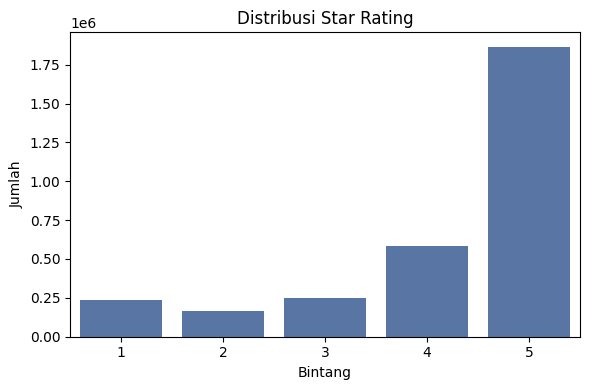

In [ ]:
dist=df.groupBy("star_rating").count().orderBy("star_rating"); dist.show()
pdf=dist.toPandas()
plt.figure(figsize=(6,4)); sns.barplot(data=pdf,x="star_rating",y="count",color="#4C72B0")
plt.title("Distribusi Star Rating"); plt.xlabel("Bintang"); plt.ylabel("Jumlah"); plt.tight_layout(); plt.show()

### 3.3 Pelabelan biner
Pelabelan dilakukan berdasarkan `star_rating` dimana 1–2★ → 0 (Negatif), 4–5★ → 1 (Positif), 3★ disisihkan (ambigu).

In [ ]:
neutral=df.filter(F.col("star_rating")==3)
print("Review 3 bintang (disisihkan):",neutral.count())
data=(df.filter(F.col("star_rating")!=3)
        .withColumn("label",F.when(F.col("star_rating")<=2,0).otherwise(1)))
data.groupBy("label").count().orderBy("label").show()

Review 3 bintang (disisihkan): 249924
+-----+-------+
|label|  count|
+-----+-------+
|    0| 404602|
|    1|2450964|
+-----+-------+



## 4. Prapemrosesan Teks (Step-by-Step)
Kita ambil **satu contoh kotor** dan terapkan pembersihan **satu operasi per sel**, mencetak hasil tiap langkah. Variabel `s` membawa hasil dari langkah sebelumnya (pola regex yang dipakai sama persis dengan yang nanti dipakai Spark pada seluruh kolom).

### 4.1 Contoh mentah

In [ ]:
raw = "LOVED this Book!! Visit <br/> http://example.com NOW... 5/5 stars :)"
s = raw
print("MENTAH:", s)

MENTAH: LOVED this Book!! Visit <br/> http://example.com NOW... 5/5 stars :)


### 4.2 Lowercase
Menyamakan huruf agar "Book" dan "book" dianggap kata sama.

In [ ]:
print("sebelum:", s)
s = s.lower()
print("sesudah:", s)

sebelum: LOVED this Book!! Visit <br/> http://example.com NOW... 5/5 stars :)
sesudah: loved this book!! visit <br/> http://example.com now... 5/5 stars :)


### 4.3 Hapus tag HTML — pola `<[^>]+>`
Membuang penanda seperti `<br/>`.

In [ ]:
print("sebelum:", s)
s = re.sub(r"<[^>]+>", " ", s)
print("sesudah:", s)

sebelum: loved this book!! visit <br/> http://example.com now... 5/5 stars :)
sesudah: loved this book!! visit   http://example.com now... 5/5 stars :)


### 4.4 Hapus URL — pola `http\S+|www\S+`

In [ ]:
print("sebelum:", s)
s = re.sub(r"http\S+|www\S+", " ", s)
print("sesudah:", s)

sebelum: loved this book!! visit   http://example.com now... 5/5 stars :)
sesudah: loved this book!! visit     now... 5/5 stars :)


### 4.5 Sisakan huruf saja — pola `[^a-z\s]`
Membuang angka & tanda baca (mis. `!!`, `5/5`, `:)`).

In [ ]:
print("sebelum:", s)
s = re.sub(r"[^a-z\s]", " ", s)
print("sesudah:", s)

sebelum: loved this book!! visit     now... 5/5 stars :)
sesudah: loved this book   visit     now        stars   


### 4.6 Rapikan spasi ganda — pola `\s+`

In [ ]:
print("sebelum:", repr(s))
s = re.sub(r"\s+", " ", s).strip()
print("sesudah:", repr(s))
print("\nMENTAH : ", raw)
print("BERSIH : ", s)

sebelum: 'loved this book   visit     now        stars   '
sesudah: 'loved this book visit now stars'

MENTAH :  LOVED this Book!! Visit <br/> http://example.com NOW... 5/5 stars :)
BERSIH :  loved this book visit now stars


### 4.7 Terapkan ke SELURUH data (Spark)
Operasi yang sama dijalankan pada kolom `review_body` untuk semua baris.

In [ ]:
clean=F.lower(F.col("review_body"))
clean=F.regexp_replace(clean,r"<[^>]+>"," ")
clean=F.regexp_replace(clean,r"http\S+|www\S+"," ")
clean=F.regexp_replace(clean,r"[^a-z\s]"," ")
clean=F.regexp_replace(clean,r"\s+"," ")
data=data.withColumn("text_clean",F.trim(clean)).filter(F.length("text_clean")>0)
data.select("review_body","text_clean").show(3,truncate=55)

+-------------------------------------------------------+-------------------------------------------------------+
|                                            review_body|                                             text_clean|
+-------------------------------------------------------+-------------------------------------------------------+
|this boook was a great one that you could learn from...|this boook was a great one that you could learn from...|
|never read it-a young relative idicated he liked it ...|never read it a young relative idicated he liked it ...|
|Though she is honored to be Chicago Woman of the Yea...|though she is honored to be chicago woman of the yea...|
+-------------------------------------------------------+-------------------------------------------------------+
only showing top 3 rows


## 5. TF-IDF (Teks → Vektor Angka)
Agar mekanismenya terlihat, kita pakai **korpus mini** 4 kalimat supaya vektornya mungil dan terbaca. Setiap tahap dicetak hasilnya.

### 5.1 Korpus mini

In [ ]:
toy=spark.createDataFrame([
    (0,"the book is amazing and brilliant"),
    (1,"the book is terrible and boring"),
    (2,"the story is amazing"),
    (3,"a boring terrible read"),
],["id","text_clean"])
toy.show(truncate=False)

+---+---------------------------------+
|id |text_clean                       |
+---+---------------------------------+
|0  |the book is amazing and brilliant|
|1  |the book is terrible and boring  |
|2  |the story is amazing             |
|3  |a boring terrible read           |
+---+---------------------------------+



### 5.2 RegexTokenizer — memecah jadi token
Teks dipotong pada tiap spasi menjadi daftar kata.

In [ ]:
tok=RegexTokenizer(inputCol="text_clean",outputCol="tokens",pattern="\\s+")
toy1=tok.transform(toy)
for r in toy1.collect(): print(f"doc{r['id']}: {r['tokens']}")

doc0: ['the', 'book', 'is', 'amazing', 'and', 'brilliant']
doc1: ['the', 'book', 'is', 'terrible', 'and', 'boring']
doc2: ['the', 'story', 'is', 'amazing']
doc3: ['a', 'boring', 'terrible', 'read']


### 5.3 StopWordsRemover — buang kata umum
Kata seperti *the, is, and, a* tak bermakna sentimen, dibuang.

In [ ]:
rem=StopWordsRemover(inputCol="tokens",outputCol="tokens_clean")
toy2=rem.transform(toy1)
for r in toy2.collect():
    removed=[w for w in r["tokens"] if w not in r["tokens_clean"]]
    print(f"doc{r['id']}: kept={r['tokens_clean']} | dibuang={removed}")

doc0: kept=['book', 'amazing', 'brilliant'] | dibuang=['the', 'is', 'and']
doc1: kept=['book', 'terrible', 'boring'] | dibuang=['the', 'is', 'and']
doc2: kept=['story', 'amazing'] | dibuang=['the', 'is']
doc3: kept=['boring', 'terrible', 'read'] | dibuang=['a']


### 5.4 CountVectorizer — Term Frequency (TF)

$$ \text{TF}(t,d)=\text{jumlah kemunculan term } t \text{ dalam dokumen } d $$

Membangun kosakata (kata → indeks), lalu tiap dokumen jadi vektor jumlah kata (disimpan sebagai *sparse vector*).

In [ ]:
cv=CountVectorizer(inputCol="tokens_clean",outputCol="tf",minDF=1.0)
cvm=cv.fit(toy2); toy3=cvm.transform(toy2)
print("Kosakata (indeks -> kata):")
for i,term in enumerate(cvm.vocabulary): print(f"  [{i}] {term}")
print("\nVektor TF (decode -> kata:jumlah):")
for r in toy3.collect():
    v=r["tf"]; dec={cvm.vocabulary[int(i)]:int(c) for i,c in zip(v.indices,v.values)}
    print(f"  doc{r['id']}: {v}  ->  {dec}")

Kosakata (indeks -> kata):
  [0] book
  [1] terrible
  [2] boring
  [3] amazing
  [4] read
  [5] story
  [6] brilliant

Vektor TF (decode -> kata:jumlah):
  doc0: (7,[0,3,6],[1.0,1.0,1.0])  ->  {'book': 1, 'amazing': 1, 'brilliant': 1}
  doc1: (7,[0,1,2],[1.0,1.0,1.0])  ->  {'book': 1, 'terrible': 1, 'boring': 1}
  doc2: (7,[3,5],[1.0,1.0])  ->  {'amazing': 1, 'story': 1}
  doc3: (7,[1,2,4],[1.0,1.0,1.0])  ->  {'terrible': 1, 'boring': 1, 'read': 1}


### 5.5 IDF — Inverse Document Frequency

Spark memakai rumus ber-*smoothing*:

$$ \text{IDF}(t)=\ln\!\left(\frac{N+1}{\text{df}(t)+1}\right), \qquad \text{TF-IDF}(t,d)=\text{TF}(t,d)\times\text{IDF}(t) $$

Di bawah, IDF dari Spark dibandingkan dengan hitungan manual rumus tersebut (harus identik).

In [ ]:
idf=IDF(inputCol="tf",outputCol="features")
idfm=idf.fit(toy3); toy4=idfm.transform(toy3)
N=toy.count()
df_counts={}
for r in toy2.collect():
    for w in set(r["tokens_clean"]): df_counts[w]=df_counts.get(w,0)+1
print(f"N={N}\n{'term':10s}{'df':>4s}{'IDF_spark':>12s}{'IDF_manual':>12s}")
for i,term in enumerate(cvm.vocabulary):
    man=np.log((N+1)/(df_counts[term]+1))
    print(f"{term:10s}{df_counts[term]:>4d}{idfm.idf[i]:>12.4f}{man:>12.4f}")
v=toy4.collect()[0]["features"]
print("\nTF-IDF doc0:",{cvm.vocabulary[int(i)]:round(float(x),4) for i,x in zip(v.indices,v.values)})
print("-> 'brilliant' (df=1, langka) berbobot > 'book' (df=2).")

N=4
term        df   IDF_spark  IDF_manual
book         2      0.5108      0.5108
terrible     2      0.5108      0.5108
boring       2      0.5108      0.5108
amazing      2      0.5108      0.5108
read         1      0.9163      0.9163
story        1      0.9163      0.9163
brilliant    1      0.9163      0.9163

TF-IDF doc0: {'book': 0.5108, 'amazing': 0.5108, 'brilliant': 0.9163}
-> 'brilliant' (df=1, langka) berbobot > 'book' (df=2).


### 5.6 Definisi tahap TF-IDF untuk data asli
Pipeline yang sama, kosakata dibatasi 20.000 & membuang term di < 5 dokumen.

In [ ]:
tokenizer=RegexTokenizer(inputCol="text_clean",outputCol="tokens",pattern="\\s+")
remover  =StopWordsRemover(inputCol="tokens",outputCol="tokens_clean")
cv_real  =CountVectorizer(inputCol="tokens_clean",outputCol="tf",vocabSize=20000,minDF=5.0)
idf_real =IDF(inputCol="tf",outputCol="features")
print("Tahap TF-IDF data asli terdefinisi.")

Tahap TF-IDF data asli terdefinisi.


## 6. Persiapan Pelatihan: Class Weight & Split
Data timpang (positif dominan). Bobot kelas $w = N/(2\,N_\text{kelas})$ memberi perhatian lebih ke kelas minoritas, lalu data dibagi 80/20.

In [ ]:
n_total=data.count(); n_pos=data.filter(F.col("label")==1).count(); n_neg=n_total-n_pos
w_pos=n_total/(2.0*n_pos); w_neg=n_total/(2.0*n_neg)
print(f"Negatif={n_neg} (w={w_neg:.3f}) | Positif={n_pos} (w={w_pos:.3f})")
data=data.withColumn("classWeight",F.when(F.col("label")==1,w_pos).otherwise(w_neg))
train,test=data.randomSplit([0.8,0.2],seed=42)
train=train.cache(); test=test.cache()
print("Train:",train.count(),"| Test:",test.count())

Negatif=404578 (w=3.529) | Positif=2450859 (w=0.583)
Train: 2283986 | Test: 571451


## 7. Model Sigmoid (Logistic Regression)

### 7.1 Fungsi sigmoid

Logistic Regression menghitung skor linear $z=w^\top x+b$ lalu memetakannya ke probabilitas:

$$ \sigma(z)=\frac{1}{1+e^{-z}} $$

Hasil 0–1; bila $\ge 0.5$ → Positif.

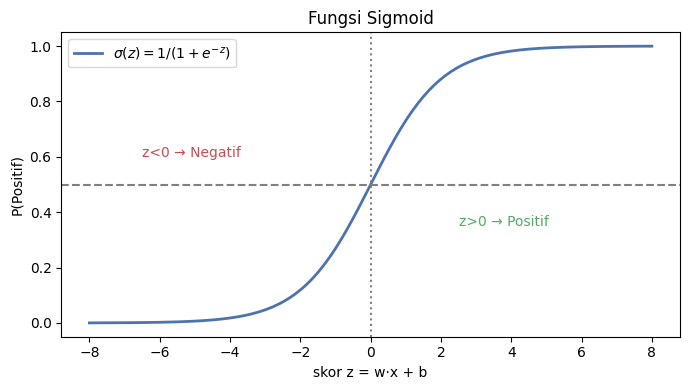

In [ ]:
xx_curve=np.linspace(-8,8,200); sig=1/(1+np.exp(-xx_curve))
plt.figure(figsize=(7,4))
plt.plot(xx_curve,sig,color="#4C72B0",lw=2,label=r"$\sigma(z)=1/(1+e^{-z})$")
plt.axhline(0.5,ls="--",color="gray"); plt.axvline(0,ls=":",color="gray")
plt.text(2.5,0.35,"z>0 → Positif",color="#55A868"); plt.text(-6.5,0.6,"z<0 → Negatif",color="#C44E52")
plt.title("Fungsi Sigmoid"); plt.xlabel("skor z = w·x + b"); plt.ylabel("P(Positif)")
plt.legend(); plt.tight_layout(); plt.show()

### 7.2 Simulasi pelatihan — penyiapan data 1-D

> ⚠️ **Disclaimer:** simulasi ini **ilustrasi konsep** memakai data **1 dimensi**, gradient descent manual, **tanpa regularisasi & tanpa class weight**. Training Spark yang sebenarnya berdimensi 20.000, memakai optimizer **L-BFGS**, `regParam=0.01` (L2), dan class weight. Karena itu **angka loss simulasi TIDAK bisa dibandingkan langsung** dengan `objectiveHistory` Spark — yang dibandingkan hanyalah *pola* (loss menurun → konvergen).

Pembaruan bobot tiap iterasi: $w \leftarrow w-\eta\,\overline{(\sigma(z)-y)x}$, $\ b \leftarrow b-\eta\,\overline{(\sigma(z)-y)}$.

In [ ]:
rng=np.random.default_rng(0)
xn=rng.normal(-2,1,80); xp=rng.normal(2,1,80)
X_sim=np.concatenate([xn,xp]); y_sim=np.concatenate([np.zeros(80),np.ones(80)])
# reset eksplisit (penting bila sel dijalankan ulang)
w, b, eta = 0.0, 0.0, 0.3
W, B, LOSS = [], [], []
for it in range(60):
    p=1/(1+np.exp(-(w*X_sim+b)))
    w-=eta*np.mean((p-y_sim)*X_sim); b-=eta*np.mean(p-y_sim)
    W.append(w); B.append(b)
    LOSS.append(-np.mean(y_sim*np.log(p+1e-9)+(1-y_sim)*np.log(1-p+1e-9)))
print(f"Data simulasi: {len(X_sim)} titik (80 negatif, 80 positif). Iterasi: 60, eta={eta}")
print("Snapshot (iterasi, w, b, loss):")
for it in [0,3,8,15,30,59]:
    print(f"  iter {it:2d}: w={W[it]:.3f}  b={B[it]:.3f}  loss={LOSS[it]:.4f}")

Data simulasi: 160 titik (80 negatif, 80 positif). Iterasi: 60, eta=0.3
Snapshot (iterasi, w, b, loss):
  iter  0: w=0.285  b=0.000  loss=0.6931
  iter  3: w=0.732  b=-0.002  loss=0.3009
  iter  8: w=1.092  b=-0.005  loss=0.1887
  iter 15: w=1.385  b=-0.008  loss=0.1423
  iter 30: w=1.760  b=-0.010  loss=0.1083
  iter 59: w=2.178  b=-0.007  loss=0.0871


### 7.3 Visualisasi sigmoid belajar tiap iterasi
Tiap panel = satu iterasi. Kurva sigmoid bergeser/menajam memisahkan negatif (bawah) dari positif (atas).

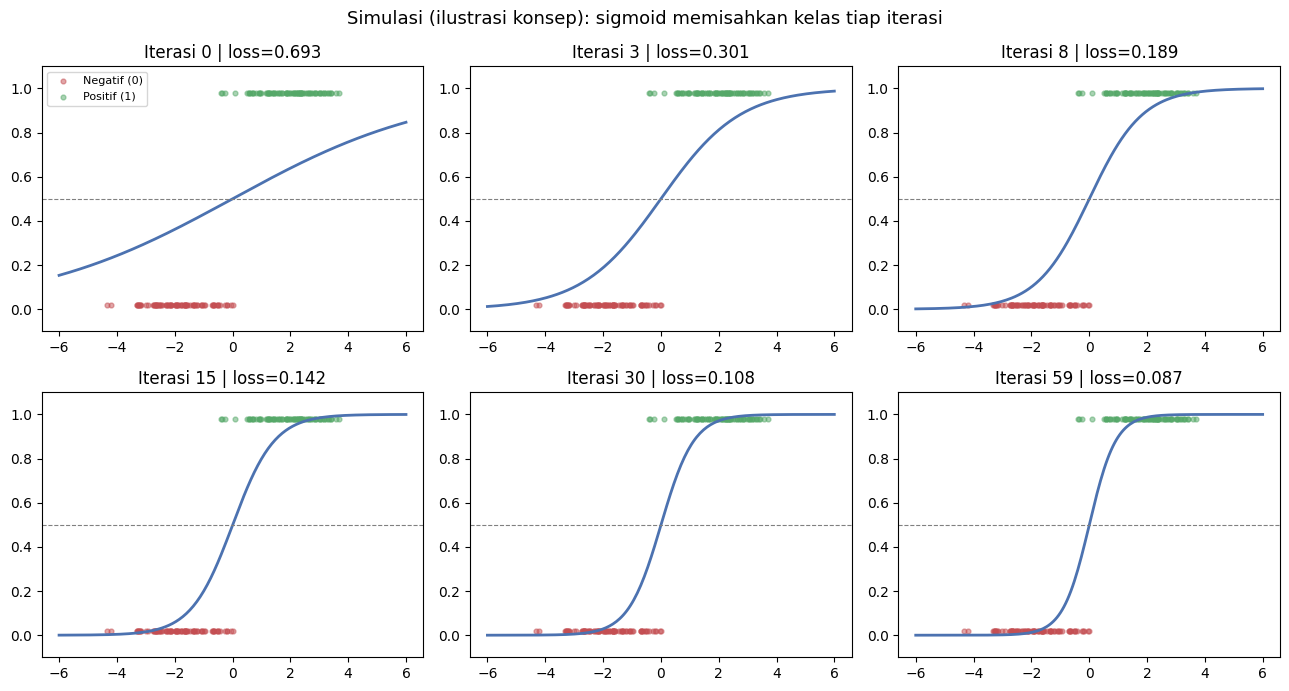

In [ ]:
snaps=[0,3,8,15,30,59]; xx_sim=np.linspace(-6,6,200)
fig,axes=plt.subplots(2,3,figsize=(13,7))
for ax,it in zip(axes.ravel(),snaps):
    ax.scatter(xn,np.zeros_like(xn)+0.02,c="#C44E52",s=12,alpha=.5,label="Negatif (0)")
    ax.scatter(xp,np.ones_like(xp)-0.02,c="#55A868",s=12,alpha=.5,label="Positif (1)")
    ax.plot(xx_sim,1/(1+np.exp(-(W[it]*xx_sim+B[it]))),color="#4C72B0",lw=2)
    ax.axhline(0.5,ls="--",color="gray",lw=.8)
    ax.set_title(f"Iterasi {it} | loss={LOSS[it]:.3f}"); ax.set_ylim(-0.1,1.1)
axes[0,0].legend(fontsize=8)
fig.suptitle("Simulasi (ilustrasi konsep): sigmoid memisahkan kelas tiap iterasi",fontsize=13)
plt.tight_layout(); plt.show()

### 7.4 Loss simulasi per iterasi

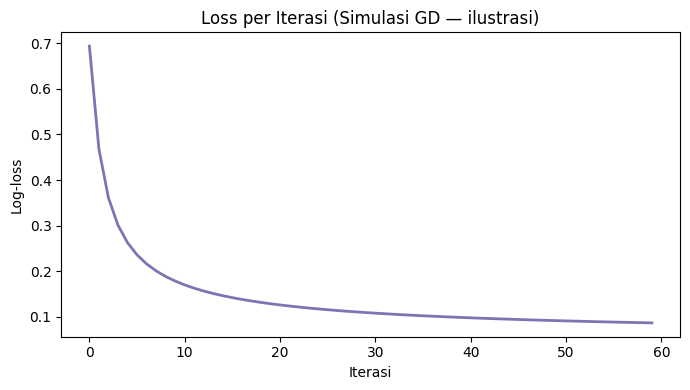

In [ ]:
plt.figure(figsize=(7,4)); plt.plot(range(len(LOSS)),LOSS,color="#8172B3",lw=2)
plt.title("Loss per Iterasi (Simulasi GD — ilustrasi)"); plt.xlabel("Iterasi"); plt.ylabel("Log-loss")
plt.tight_layout(); plt.show()

### 7.5 Melatih model pada data asli
Pipeline lengkap TF-IDF → Logistic Regression (sigmoid) + class weight. Hyperparameter ditulis **eksplisit**.

In [ ]:
lr=LogisticRegression(featuresCol="features",labelCol="label",weightCol="classWeight",
                      maxIter=20, regParam=0.01, elasticNetParam=0.0)   # L2 murni
pipeline=Pipeline(stages=[tokenizer,remover,cv_real,idf_real,lr])
print("Melatih... (beberapa menit pada data penuh)")
model=pipeline.fit(train)
lrm=model.stages[-1]; cvm_real=model.stages[2]
pred=model.transform(test)
print("Selesai. Parameter:",
      "maxIter=",lr.getMaxIter(),"| regParam=",lr.getRegParam(),"| elasticNetParam=",lr.getElasticNetParam())

Melatih... (beberapa menit pada data penuh)
Selesai. Parameter: maxIter= 20 | regParam= 0.01 | elasticNetParam= 0.0


### 7.6 Konvergensi nyata (objectiveHistory)
Loss per iterasi dari pelatihan Spark yang sebenarnya. (Bandingkan **polanya** dengan simulasi — bukan angkanya, karena optimizer & setting berbeda.)

objectiveHistory: [0.6931, 0.3884, 0.3791, 0.3393, 0.3215, 0.31, 0.3022, 0.299, 0.2968, 0.2954, 0.2941, 0.2938, 0.2932, 0.2932, 0.293, 0.2929, 0.2929, 0.2929, 0.2929, 0.2929, 0.2929]


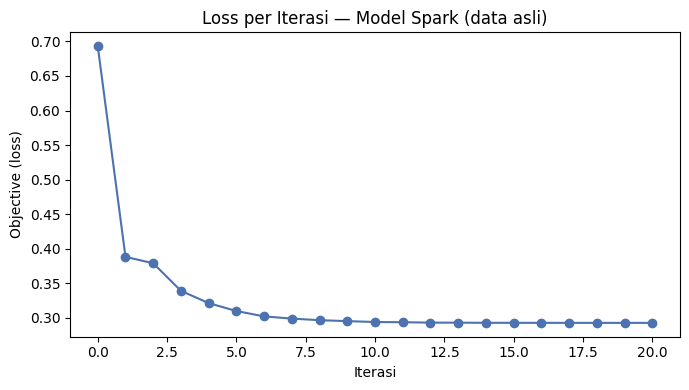

In [ ]:
hist=lrm.summary.objectiveHistory
print("objectiveHistory:",[round(h,4) for h in hist])
plt.figure(figsize=(7,4)); plt.plot(range(len(hist)),hist,marker="o",color="#4C72B0")
plt.title("Loss per Iterasi — Model Spark (data asli)"); plt.xlabel("Iterasi"); plt.ylabel("Objective (loss)")
plt.tight_layout(); plt.show()

### 7.7 Sigmoid pada ulasan nyata
Untuk beberapa ulasan uji: skor $z=\ln\frac{P_1}{P_0}$ (kebalikan sigmoid), probabilitas $P(\text{Positif})$, prediksi, dan label asli.

In [ ]:
samp=pred.select("text_clean","label","probability","prediction").limit(8).toPandas()
samp["P_positif"]=samp["probability"].apply(lambda v: float(v[1]))
pc=samp["P_positif"].clip(1e-9,1-1e-9)
samp["z"]=np.log(pc/(1-pc))
samp["cuplikan"]=samp["text_clean"].str.slice(0,42)+"..."
print(samp[["cuplikan","z","P_positif","prediction","label"]].round(3).to_string(index=False))
# verifikasi konsistensi (bukan kolom baru): sigmoid(z) harus = P_positif
err=np.max(np.abs(1/(1+np.exp(-samp["z"]))-samp["P_positif"]))
print(f"\nVerifikasi sigmoid: max|σ(z) − P_positif| = {err:.2e}  (≈0 → konsisten dengan teori)")

                                     cuplikan     z  P_positif  prediction  label
i recently purchased this book and am thri... 4.210      0.985         1.0      1
easy read topical subject matter leans rig... 1.194      0.767         1.0      1
congratulations on a great book we put int... 2.237      0.904         1.0      1
i am a huge werewolf fan especially of lyc... 1.730      0.849         1.0      1
it must be difficult given the plethora of... 3.416      0.968         1.0      1
mark and alissa s creative tax planner tak... 1.707      0.846         1.0      1
i haven t read a good book in a long time ... 3.435      0.969         1.0      1
dr susan ashley really got it right with t... 2.950      0.950         1.0      1

Verifikasi sigmoid: max|σ(z) − P_positif| = 1.11e-16  (≈0 → konsisten dengan teori)


### 7.8 Sebaran hasil Positif vs Negatif
(a) histogram probabilitas dipisah label; (b) ulasan nyata pada kurva sigmoid (diwarnai label).

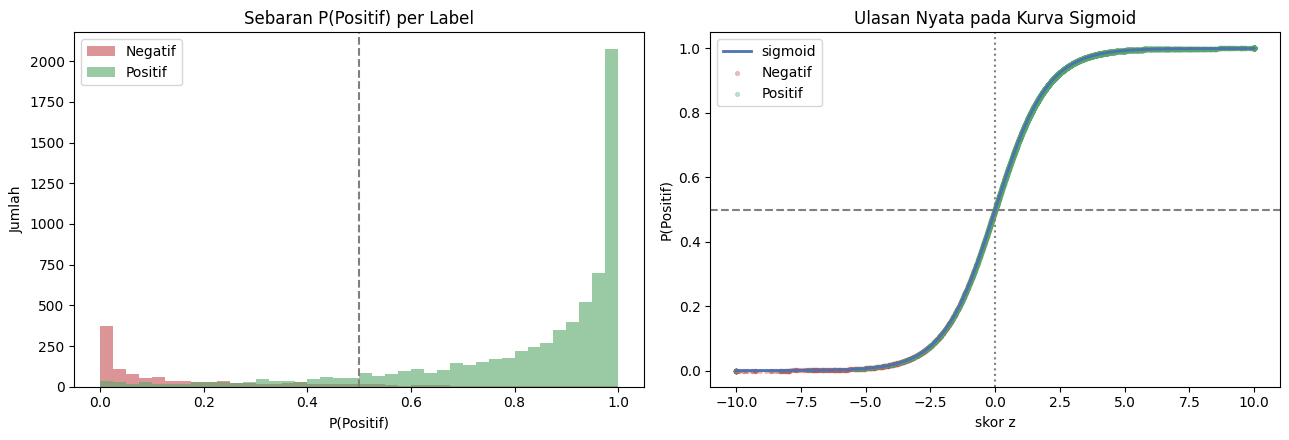

In [ ]:
sp=(pred.select("label","probability").sample(False,0.02,seed=42).limit(8000).toPandas())
sp["P_positif"]=sp["probability"].apply(lambda v: float(v[1]))
pc2=sp["P_positif"].clip(1e-9,1-1e-9); sp["z"]=np.log(pc2/(1-pc2))
xx_real=np.linspace(-10,10,200)
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
for lbl,c,nm in [(0,"#C44E52","Negatif"),(1,"#55A868","Positif")]:
    ax[0].hist(sp[sp.label==lbl]["P_positif"],bins=40,alpha=.6,color=c,label=nm)
ax[0].axvline(0.5,ls="--",color="gray"); ax[0].set_title("Sebaran P(Positif) per Label")
ax[0].set_xlabel("P(Positif)"); ax[0].set_ylabel("Jumlah"); ax[0].legend()
ax[1].plot(xx_real,1/(1+np.exp(-xx_real)),color="#4C72B0",lw=2,zorder=3,label="sigmoid")
for lbl,c,nm in [(0,"#C44E52","Negatif"),(1,"#55A868","Positif")]:
    s=sp[sp.label==lbl]; ax[1].scatter(s["z"].clip(-10,10),s["P_positif"],s=8,alpha=.3,color=c,label=nm)
ax[1].axhline(0.5,ls="--",color="gray"); ax[1].axvline(0,ls=":",color="gray")
ax[1].set_title("Ulasan Nyata pada Kurva Sigmoid"); ax[1].set_xlabel("skor z"); ax[1].set_ylabel("P(Positif)"); ax[1].legend()
plt.tight_layout(); plt.show()

### 7.9 Kurva ROC
ROC memplot True Positive Rate vs False Positive Rate pada berbagai ambang. Luas di bawahnya = **AUC**.

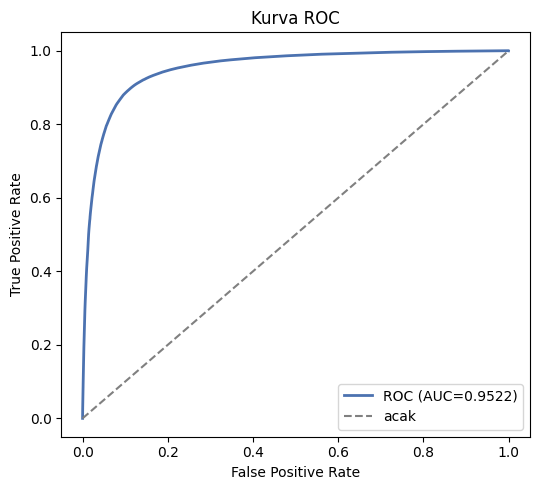

In [ ]:
feat=pred.drop("rawPrediction","probability","prediction")
summ=lrm.evaluate(feat)
roc=summ.roc.toPandas()
plt.figure(figsize=(5.5,5))
plt.plot(roc["FPR"],roc["TPR"],color="#4C72B0",lw=2,label=f"ROC (AUC={summ.areaUnderROC:.4f})")
plt.plot([0,1],[0,1],ls="--",color="gray",label="acak")
plt.title("Kurva ROC"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

### 7.10 Kata paling berpengaruh
Koefisien Logistic Regression dipetakan ke kosakata. Koefisien besar positif → mendorong **Positif**; besar negatif → mendorong **Negatif**.

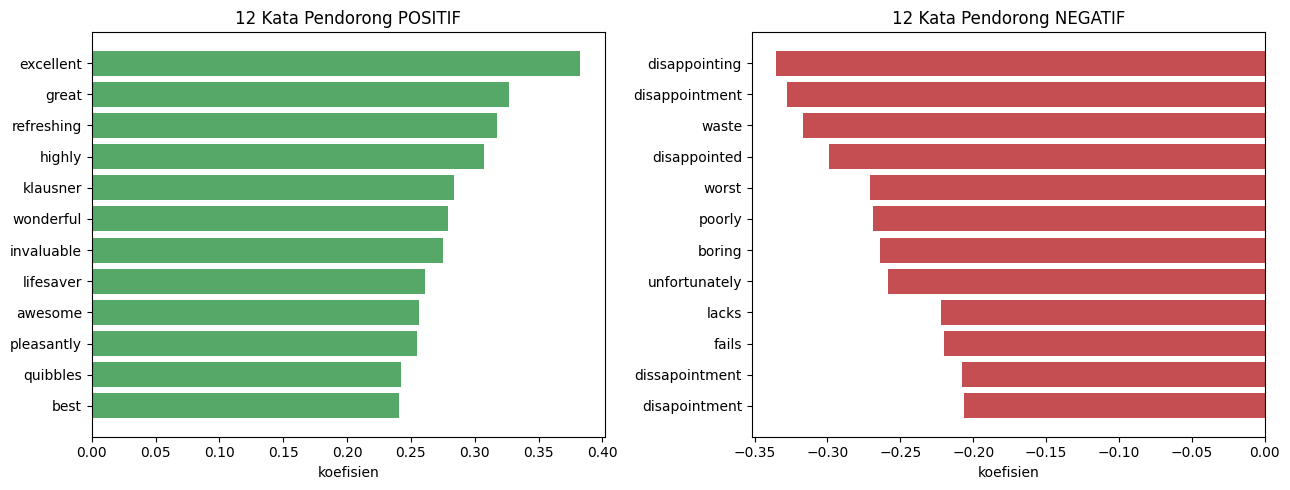

In [ ]:
coefs=lrm.coefficients.toArray(); vocab=cvm_real.vocabulary
order=np.argsort(coefs)
top_pos=[(vocab[i],coefs[i]) for i in order[::-1][:12]]
top_neg=[(vocab[i],coefs[i]) for i in order[:12]]
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].barh([w for w,_ in top_pos][::-1],[c for _,c in top_pos][::-1],color="#55A868")
ax[0].set_title("12 Kata Pendorong POSITIF"); ax[0].set_xlabel("koefisien")
ax[1].barh([w for w,_ in top_neg][::-1],[c for _,c in top_neg][::-1],color="#C44E52")
ax[1].set_title("12 Kata Pendorong NEGATIF"); ax[1].set_xlabel("koefisien")
plt.tight_layout(); plt.show()

## 8. Evaluasi

### 8.1 Confusion matrix & metrik (termasuk Macro-F1)

In [ ]:
cm_rows=pred.groupBy("label","prediction").count().collect()
cm=np.zeros((2,2),dtype=int)
for r in cm_rows: cm[int(r["label"])][int(r["prediction"])]=r["count"]
print("Confusion Matrix [baris=aktual, kolom=prediksi]:")
print(pd.DataFrame(cm,index=["Aktual Neg(0)","Aktual Pos(1)"],columns=["Pred Neg(0)","Pred Pos(1)"]))
def per_class(cm,c):
    tp=cm[c,c]; fn=cm[c,:].sum()-tp; fp=cm[:,c].sum()-tp
    p=tp/(tp+fp) if (tp+fp) else 0; r=tp/(tp+fn) if (tp+fn) else 0
    f=2*p*r/(p+r) if (p+r) else 0; return p,r,f
p0,r0,f0=per_class(cm,0); p1,r1,f1=per_class(cm,1)
ev=MulticlassClassificationEvaluator(labelCol="label",predictionCol="prediction")
acc=ev.evaluate(pred,{ev.metricName:"accuracy"})
auc=BinaryClassificationEvaluator(labelCol="label",rawPredictionCol="rawPrediction",metricName="areaUnderROC").evaluate(pred)
report=pd.DataFrame({"Precision":[p0,p1],"Recall":[r0,r1],"F1-score":[f0,f1]},index=["Negatif (0)","Positif (1)"])
report.loc["Rata-rata Makro"]=report.mean()
print(f"\nAccuracy={acc:.4f} | AUC-ROC={auc:.4f} | Macro-F1={report.loc['Rata-rata Makro','F1-score']:.4f}")
print(report.round(4))

Confusion Matrix [baris=aktual, kolom=prediksi]:
               Pred Neg(0)  Pred Pos(1)
Aktual Neg(0)        71310         9397
Aktual Pos(1)        48337       442407

Accuracy=0.8990 | AUC-ROC=0.9522 | Macro-F1=0.8253
                 Precision  Recall  F1-score
Negatif (0)         0.5960  0.8836    0.7118
Positif (1)         0.9792  0.9015    0.9387
Rata-rata Makro     0.7876  0.8925    0.8253


### 8.2 Visualisasi evaluasi

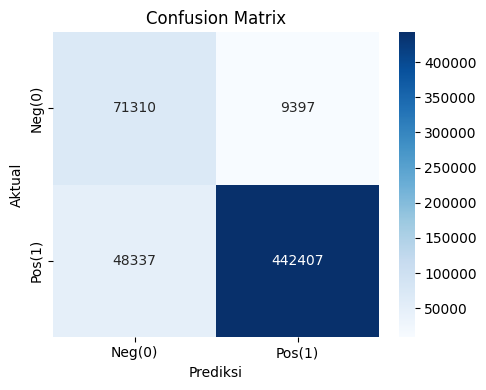

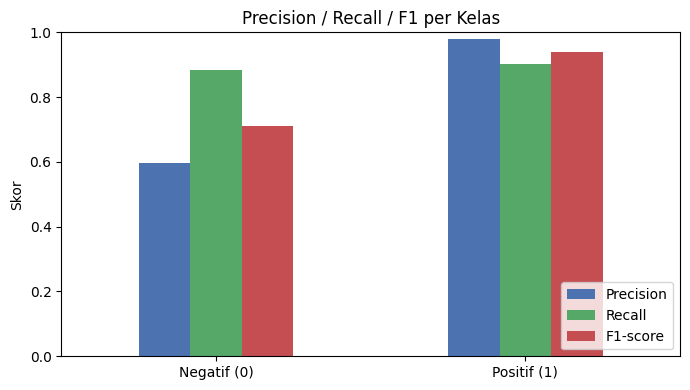

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Neg(0)","Pos(1)"],yticklabels=["Neg(0)","Pos(1)"])
plt.title("Confusion Matrix"); plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.tight_layout(); plt.show()
report.drop("Rata-rata Makro").plot(kind="bar",figsize=(7,4),ylim=(0,1),rot=0,color=["#4C72B0","#55A868","#C44E52"])
plt.title("Precision / Recall / F1 per Kelas"); plt.ylabel("Skor"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 9. Kesimpulan
Model Logistic Regression yang dibangun mencapai Accuracy 89,90% dan AUC-ROC sebesar 0,952. Model sigmoid (Logistic Regression) + TF-IDF dilatih di Spark pada seluruh data. Tahap prapemrosesan, vektorisasi, dan mekanisme sigmoid telah ditampilkan langkah demi langkah; simulasi memperlihatkan cara sigmoid memisahkan kelas tiap iterasi (ilustrasi konsep), dan `objectiveHistory` membuktikan konvergensi pada data asli. Kurva ROC, sebaran probabilitas, dan kata-kata berpengaruh memperkuat interpretasi. Metrik utama yang dilaporkan: **Macro-F1** dan **recall kelas Negatif**.